In [ ]:
!pip install -q kagglehub tensorflow scikit-learn seaborn pillow matplotlib

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import kagglehub

from pathlib import Path
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
SEED = 42
IMG_SIZE = (180, 180)
BATCH_SIZE = 32
EPOCHS = 30

tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [ ]:
dataset_path = kagglehub.dataset_download("alessiocorrado99/animals10")
print(dataset_path)

Using Colab cache for faster access to the 'animals10' dataset.
/kaggle/input/animals10


In [ ]:
def find_dataset_directory(base_path):
    base = Path(base_path)
    candidates = []
    for path in base.rglob("*"):
        if path.is_dir():
            subdirs = [p for p in path.iterdir() if p.is_dir()]
            valid = 0
            for subdir in subdirs:
                count = sum(
                    1 for f in subdir.iterdir()
                    if f.is_file() and f.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
                )
                if count > 0:
                    valid += 1
            if valid >= 2:
                candidates.append((valid, path))
    if not candidates:
        raise FileNotFoundError("Could not find the image class directory.")
    candidates.sort(key=lambda x: (x[0], len(str(x[1]))), reverse=True)
    return candidates[0][1]

data_dir = find_dataset_directory(dataset_path)
print(data_dir)
print(sorted([p.name for p in data_dir.iterdir() if p.is_dir()]))

/kaggle/input/animals10/raw-img
['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


{'cane': 4863, 'cavallo': 2623, 'elefante': 1446, 'farfalla': 2112, 'gallina': 3098, 'gatto': 1668, 'mucca': 1866, 'pecora': 1820, 'ragno': 4821, 'scoiattolo': 1862}


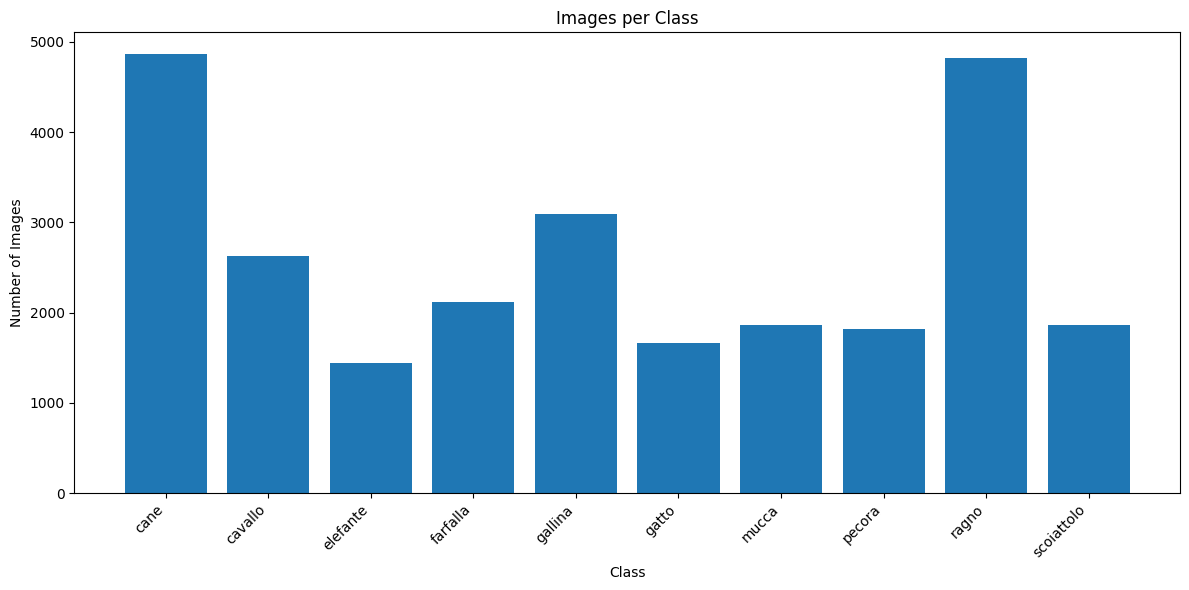

In [ ]:
class_counts = {}

for class_dir in sorted([p for p in data_dir.iterdir() if p.is_dir()]):
    count = sum(
        1 for f in class_dir.iterdir()
        if f.is_file() and f.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    )
    class_counts[class_dir.name] = count

print(class_counts)

plt.figure(figsize=(12, 6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45, ha="right")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Images per Class")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=300)
plt.show()

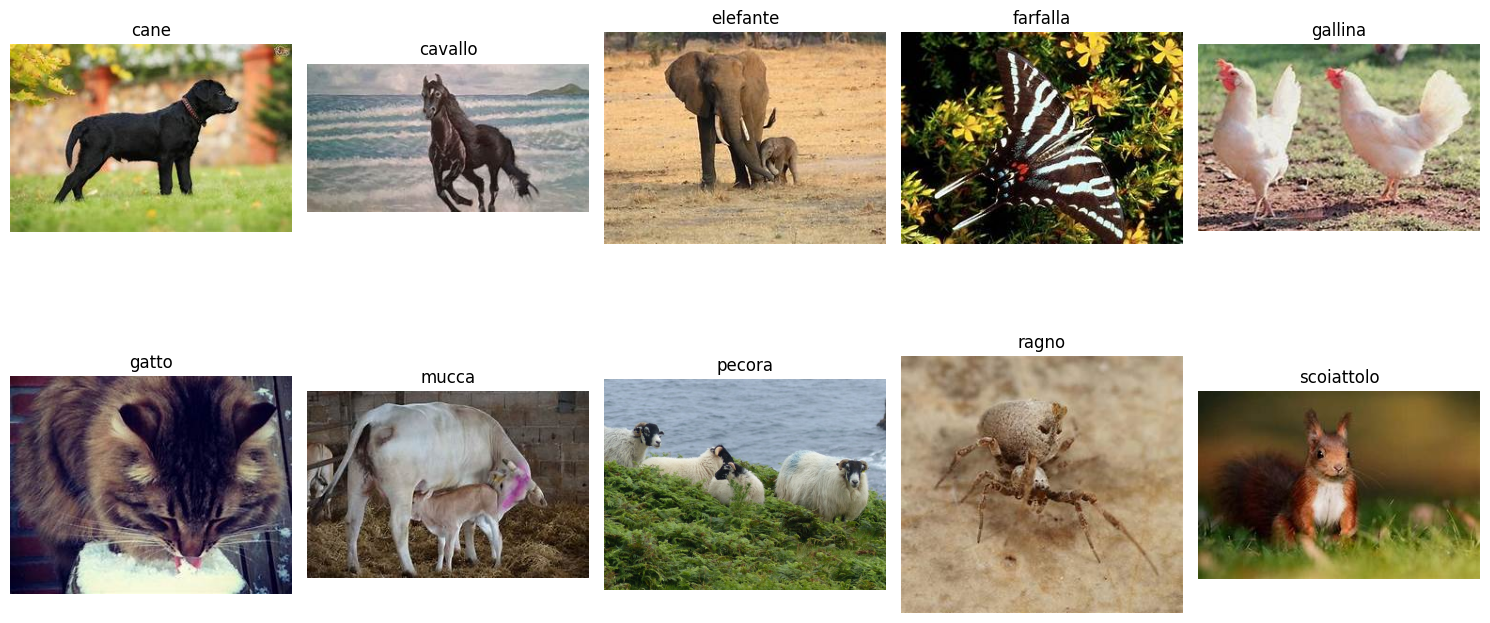

In [ ]:
class_dirs = sorted([p for p in data_dir.iterdir() if p.is_dir()], key=lambda p: p.name.lower())

plt.figure(figsize=(15, 8))

for i, class_dir in enumerate(class_dirs[:10]):
    image_files = [
        f for f in class_dir.iterdir()
        if f.is_file() and f.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    ]
    if not image_files:
        continue
    image_path = random.choice(image_files)
    image = Image.open(image_path).convert("RGB")
    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(class_dir.name)
    plt.axis("off")

plt.tight_layout()
plt.savefig("sample_images.png", dpi=300)
plt.show()

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_dataset.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 26179 files belonging to 10 classes.
Using 20944 files for training.
Found 26179 files belonging to 10 classes.
Using 5235 files for validation.
Classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
Number of classes: 10


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
])

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    data_augmentation,
    layers.Rescaling(1.0 / 255.0),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(256, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.50),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     7,930,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,321,098 (31.74 MB)

 Trainable params: 8,321,098 (31.74 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    ),
    keras.callbacks.ModelCheckpoint(
        "wildlife_cnn_best.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 147s 94ms/step - accuracy: 0.2923 - loss: 1.9983 - val_accuracy: 0.4002 - val_loss: 1.7277 - learning_rate: 0.0010
Epoch 2/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 114s 94ms/step - accuracy: 0.4584 - loss: 1.5957 - val_accuracy: 0.5358 - val_loss: 1.3633 - learning_rate: 0.0010
Epoch 3/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 97s 75ms/step - accuracy: 0.5178 - loss: 1.4210 - val_accuracy: 0.5994 - val_loss: 1.1902 - learning_rate: 0.0010
Epoch 4/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 73s 73ms/step - accuracy: 0.5560 - loss: 1.3300 - val_accuracy: 0.6019 - val_loss: 1.1779 - learning_rate: 0.0010
Epoch 5/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 77s 74ms/step - accuracy: 0.5768 - loss: 1.2522 - val_accuracy: 0.6355 - val_loss: 1.0952 - learning_rate: 0.0010
Epoch 6/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 74s 73ms/step - accuracy: 0.6009 - loss: 1.1810 - val_accuracy: 0.6038 - val_loss: 1.2010 - learning_rate: 0.0010
Epoch 7/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 73s 73ms/step - accuracy: 0.6199 -

In [ ]:
best_model = keras.models.load_model("wildlife_cnn_best.keras")

loss, accuracy = best_model.evaluate(validation_dataset, verbose=1)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)
print("Validation Accuracy (%):", accuracy * 100)

164/164 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.7417 - loss: 0.7750
Validation Loss: 0.7749937176704407
Validation Accuracy: 0.7417383193969727
Validation Accuracy (%): 74.17383193969727


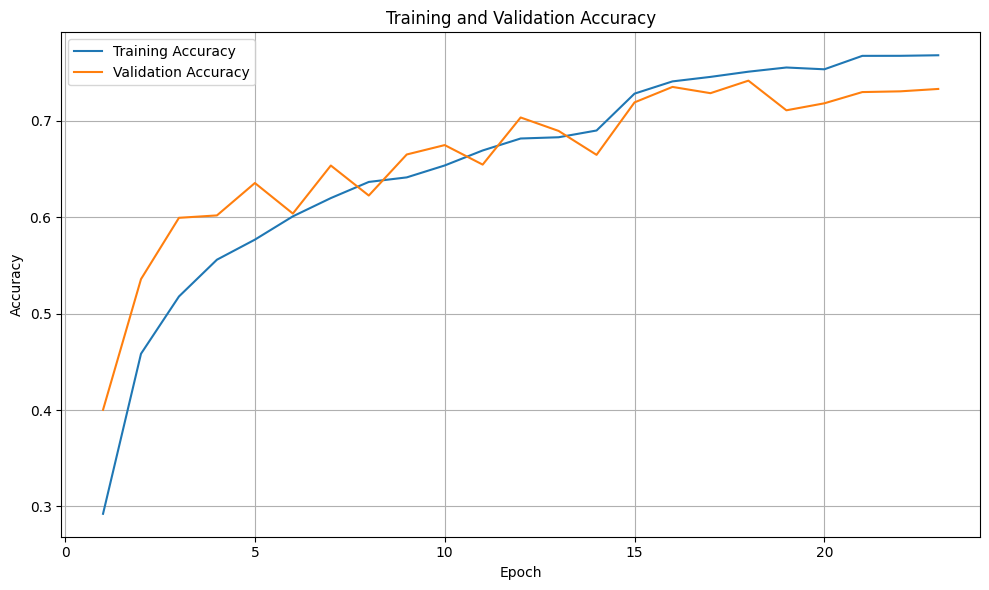

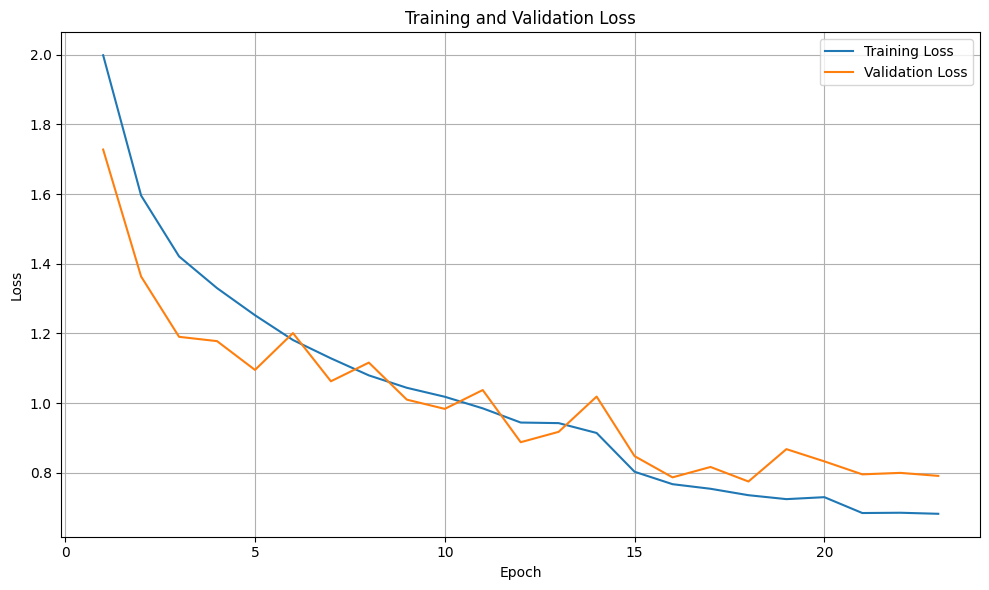

In [ ]:
history_dict = history.history
epochs_range = range(1, len(history_dict["accuracy"]) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, history_dict["accuracy"], label="Training Accuracy")
plt.plot(epochs_range, history_dict["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("accuracy_graph.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, history_dict["loss"], label="Training Loss")
plt.plot(epochs_range, history_dict["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_graph.png", dpi=300)
plt.show()

In [ ]:
y_true = []
y_pred = []

for images, labels in validation_dataset:
    probabilities = best_model.predict(images, verbose=0)
    predictions = np.argmax(probabilities, axis=1)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(predictions.tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

              precision    recall  f1-score   support

        cane       0.76      0.74      0.75       956
     cavallo       0.75      0.71      0.73       534
    elefante       0.66      0.85      0.74       256
    farfalla       0.61      0.91      0.73       406
     gallina       0.83      0.86      0.84       641
       gatto       0.65      0.41      0.50       303
       mucca       0.63      0.59      0.61       364
      pecora       0.70      0.61      0.65       363
       ragno       0.88      0.80      0.84      1025
  scoiattolo       0.66      0.72      0.69       387

    accuracy                           0.74      5235
   macro avg       0.71      0.72      0.71      5235
weighted avg       0.75      0.74      0.74      5235



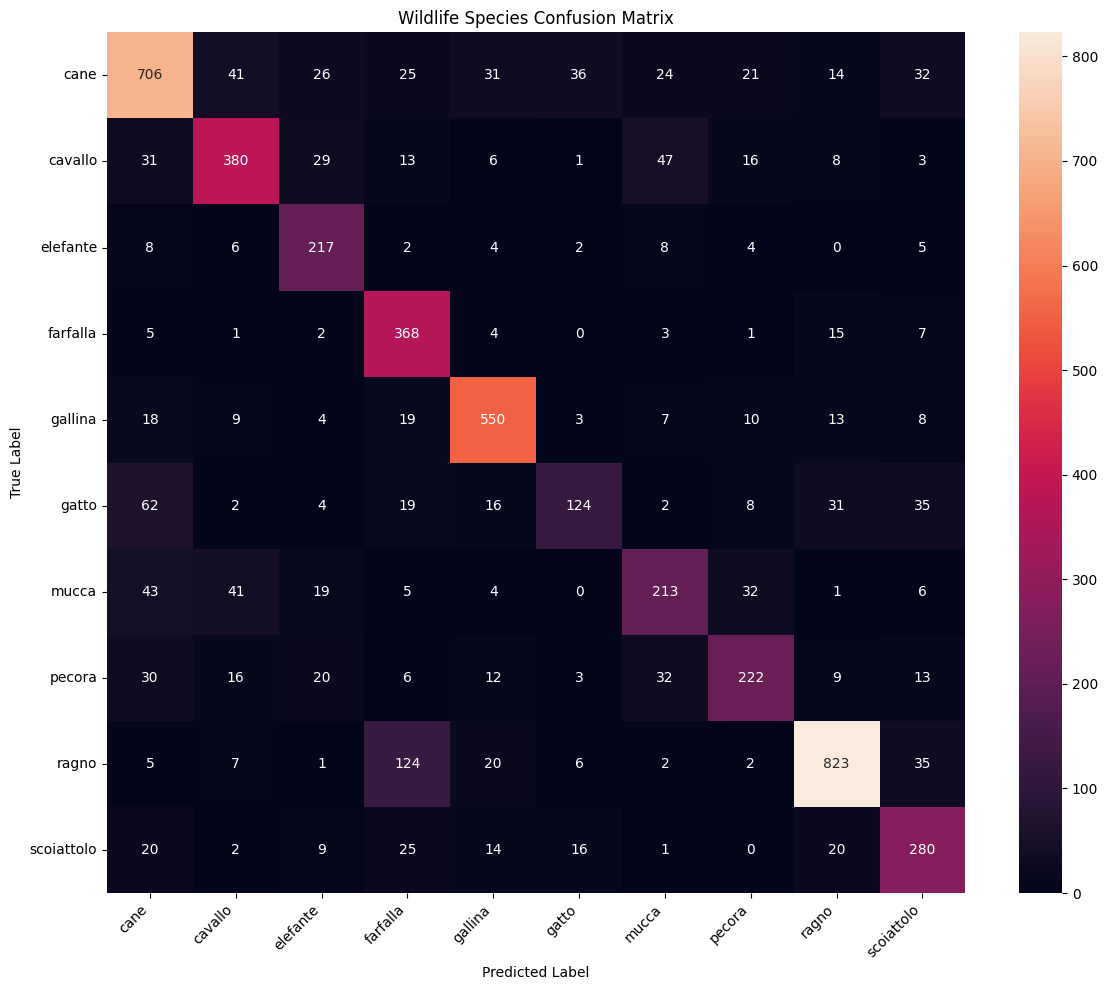

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Wildlife Species Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
wrong_items = []

for images, labels in validation_dataset:
    probabilities = best_model.predict(images, verbose=0)
    predictions = np.argmax(probabilities, axis=1)

    for i in range(len(labels)):
        true_index = int(labels[i].numpy())
        pred_index = int(predictions[i])
        if true_index != pred_index:
            wrong_items.append((
                images[i].numpy().astype("uint8"),
                class_names[true_index],
                class_names[pred_index],
                float(np.max(probabilities[i]))
            ))

print("Incorrect predictions:", len(wrong_items))

Incorrect predictions: 1352


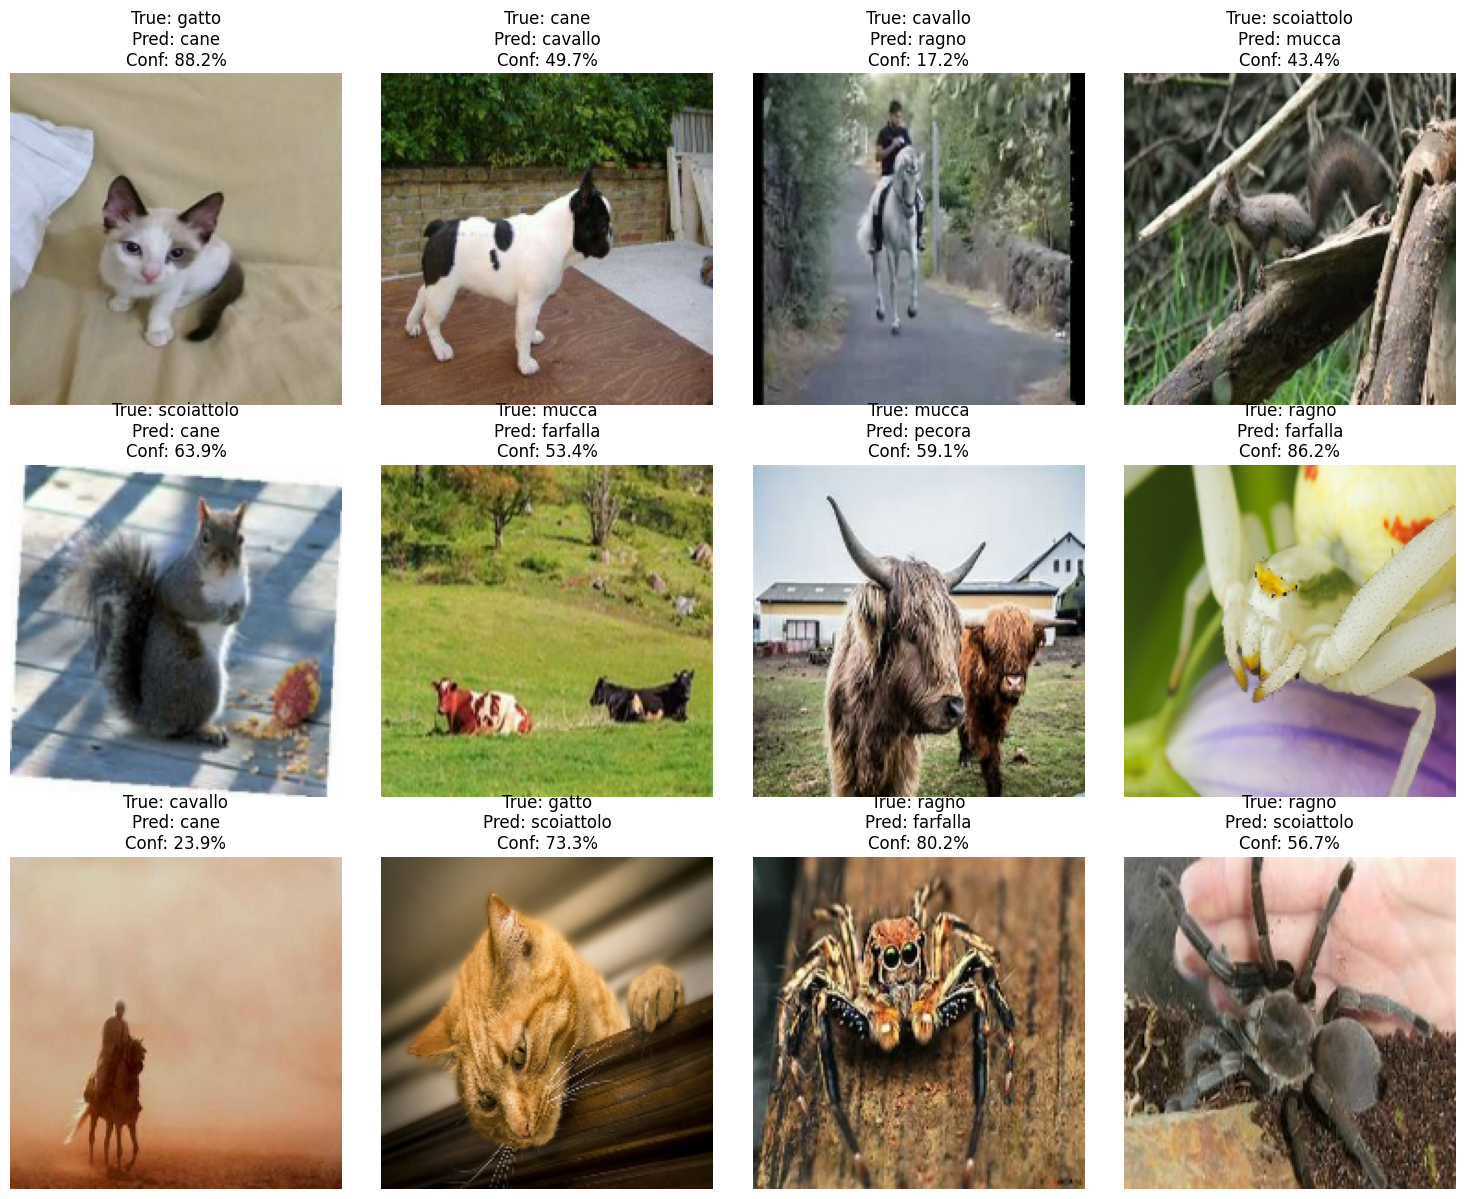

In [ ]:
show_count = min(12, len(wrong_items))

if show_count > 0:
    plt.figure(figsize=(15, 12))
    for i in range(show_count):
        image, true_name, pred_name, confidence = wrong_items[i]
        plt.subplot(3, 4, i + 1)
        plt.imshow(image)
        plt.title(
            f"True: {true_name}\nPred: {pred_name}\nConf: {confidence * 100:.1f}%"
        )
        plt.axis("off")
    plt.tight_layout()
    plt.savefig("misclassified_images.png", dpi=300)
    plt.show()
else:
    print("No misclassified images found.")

In [ ]:
best_model.save("wildlife_cnn.keras")

print("Saved:")
print("wildlife_cnn.keras")
print("wildlife_cnn_best.keras")
print("accuracy_graph.png")
print("loss_graph.png")
print("confusion_matrix.png")
print("misclassified_images.png")
print("class_distribution.png")
print("sample_images.png")

Saved:
wildlife_cnn.keras
wildlife_cnn_best.keras
accuracy_graph.png
loss_graph.png
confusion_matrix.png
misclassified_images.png
class_distribution.png
sample_images.png


In [ ]:
def predict_image(image_path):
    image = keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )
    array = keras.utils.img_to_array(image)
    array = tf.expand_dims(array, 0)

    probabilities = best_model.predict(array, verbose=0)[0]
    index = int(np.argmax(probabilities))
    confidence = float(probabilities[index])

    return class_names[index], confidence

print("Prediction function is ready.")

Prediction function is ready.


In [ ]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded:
    predicted_class, confidence = predict_image(filename)
    print("Image:", filename)
    print("Predicted Class:", predicted_class)
    print("Confidence:", f"{confidence * 100:.2f}%")

Saving Dog image.avif to Dog image (1).avif
Image: Dog image (1).avif
Predicted Class: cane
Confidence: 61.49%


In [ ]:
import os

required_files = [
    "wildlife_cnn.keras",
    "wildlife_cnn_best.keras",
    "accuracy_graph.png",
    "loss_graph.png",
    "confusion_matrix.png",
    "misclassified_images.png",
    "class_distribution.png",
    "sample_images.png"
]

for file in required_files:
    print(file, "OK" if os.path.exists(file) else "MISSING")

wildlife_cnn.keras OK
wildlife_cnn_best.keras OK
accuracy_graph.png OK
loss_graph.png OK
confusion_matrix.png OK
misclassified_images.png OK
class_distribution.png OK
sample_images.png OK
